# SHM catch in the act (v6)

## Notes:

- With references generated as Kees did in the first analysis
- This new dataset has events in K5B_S8934 light chain!!! 
- **New filtering strategy, first we are going to try to filter by:**
    - doublet detection
    - percetage of UMIs that support the variant
- how much is the quality filtering of our reads?? all reads with less of 25% of the bases >30 were descarted
- Consesus sequence used to generate the SHM output are: 95% vdj, 100% cdr, 2 reads and productive

In [1]:
#Load packages
options(warn=-1)
library("IRdisplay")
library(tidyverse)
library(fs)
library(stringr)
library(viridis)
library(ggpubr)
library(ggplot2)
#library(ggExtra)
library(Seurat)
library(Biostrings) # this package interfer with dplyr
library(data.table)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2     ✔ tidyr     1.3.0
✔ purrr     1.0.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: viridisLite

The legacy packages maptools, rgdal, and rgeos, underpinning the sp package,
which was just loaded, will retire in October 20

In [2]:
suppressMessages(source("code/functions.R"))

In [3]:
s_theme <- function() {
      t <- theme_classic() + theme(
        legend.position = "none",
        text = element_text(size = 15),
        axis.text.x = element_text(color = "black",size= 7),
        axis.text = element_text(size= 5),
        axis.title = element_text(size = 7), 
        legend.title = element_text(size = 7),legend.text=element_text(size=5),
        strip.text.x = element_text(size = 7),
        strip.background = element_blank(),
        plot.title = element_text(hjust = 0.5, size = 7)
      )
    
      return(t)
}

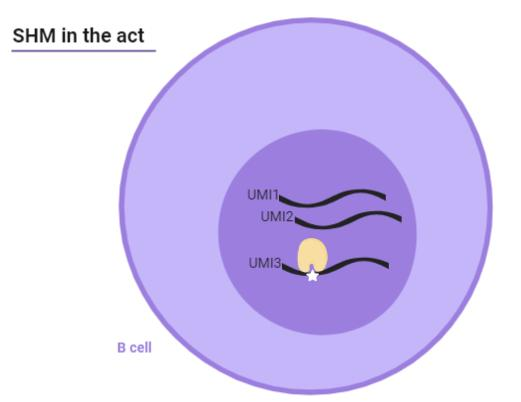

In [4]:
display_png(file="figs/shm-aid.jpeg")  

### Load input data (raw data)

- (!) Filter 0 We only consider cells with 100% coverage VDJ region

In [5]:
df_seq <- Sys.glob("input/output_shm_20220819/*/consensus/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x)) %>%
      filter(ref_vdj_coverage == '1.0')
  })

In [6]:
head(df_seq)

cell,umi,nreads,ref_vdj_coverage,ref_cdr_coverage,consensus,aligned_consensus,depths,subject
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AAACCTGAGAGACGAA,ACAAGGTCAA,502,1.0,1.0,GGGGAGAGGAGCCCCAGCCTTGGGATTCCCAAGTGTTTTCATTCAGTGATCAGGACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAGCTGGATTTTCCTTGCTACTATTTTAAAAGGTGTCCAGTGTGAGGTGCAGTTGGTGGAGTCTGGGGGAGACTTCGTAAAGCCGGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCAGGATTCAATTTTAATGACGCCTGGATGAATTGGGTCCGCCAGGCTCCAGGAAAGGGACTGGAGTGGATTGGCCATATTAAAAGTAAATTTCATGGTGAGACAACAGACTATGCCACACCCGTGAAAGGCAGATTCGTCATCTCAAGAGATGATTCAAAAGAGACTCTGTATCTACAAATGACGAGCCTGAGAACCGAGGACACAGCCATATATTATTGCAATAAAAATATTACATTGATGTTTGTGACTGGCAACTTTTCGGCTTTTGATCTCTGGGGCCAAGGGACAATGGTCACCGTCTCTTCAGCCTCCACCAAGGGCCCATCGGTCTTCCCCCTGGCGCCCTGCTCCAGGAGCACCTCCGAGAGCACAGCGGCCCTGGGCTGCCTGGTCAAGGACTACTTCCCCGAACCGGTGACGGTGTCGTGGAACTCAGGCGCCCTGACCAGCGGCGTGCACAC,NNNNNGGGGAGAGGAGCCCCAGCCTTGGGATTCCCAAGTGTTTTCATTCAGTGATCAGGACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAGCTGGATTTTCCTTGCTACTATTTTAAAAGGTGTCCAGTGTGAGGTGCAGTTGGTGGAGTCTGGGGGAGACTTCGTAAAGCCGGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCAGGATTCAATTTTAATGACGCCTGGATGAATTGGGTCCGCCAGGCTCCAGGAAAGGGACTGGAGTGGATTGGCCATATTAAAAGTAAATTTCATGGTGAGACAACAGACTATGCCACACCCGTGAAAGGCAGATTCGTCATCTCAAGAGATGATTCAAAAGAGACTCTGTATCTACAAATGACGAGCCTGAGAACCGAGGACACAGCCATATATTATTGCAATAAAAATATTACATTGATGTTTGTGACTGGCAACTTTTCGGCTTTTGATCTCTGGGGCCAAGGGACAATGGTCACCGTCTCTTCAGCCTCCACCAAGGGCCCATCGGTCTTCCCCCTGGCGCCCTGCTCCAGGAGCACCTCCGAGAGCACAGCGGCCCTGGGCTGCCTGGTCAAGGACTACTTCCCCGAACCGGTGACGGTGTCGTGGAACTCAGGCGCCCTGACCAGCGGCGTGCACACNNNNNNNNNNNNNNNNNNNNNNNNNNNN,0;0;0;0;0;8;260;268;268;273;274;274;275;276;279;279;281;281;281;282;282;285;285;285;287;287;287;287;288;288;291;292;292;293;293;297;298;300;301;301;301;301;301;302;302;302;302;302;302;303;303;303;305;305;304;305;304;304;305;305;305;303;303;305;305;307;307;307;306;306;306;307;308;307;308;307;307;308;308;309;309;309;312;312;312;312;311;311;310;309;310;310;310;309;309;308;309;309;310;310;310;311;310;311;312;310;311;309;309;307;293;77;73;72;72;70;70;69;69;69;69;69;69;67;67;67;67;66;66;66;65;66;65;65;65;65;64;64;66;66;66;64;65;65;63;63;63;62;61;61;60;61;62;62;61;58;58;58;57;61;61;61;61;61;61;61;61;61;61;60;60;58;56;56;55;55;51;51;50;49;49;50;51;53;53;59;59;62;62;62;61;61;61;59;59;59;58;60;60;59;58;59;59;59;56;56;56;56;56;56;56;55;55;55;54;54;55;56;58;58;57;56;55;53;53;53;54;54;56;56;56;54;53;53;53;53;53;53;54;53;53;50;49;49;49;48;48;48;48;48;47;47;48;51;51;51;51;51;51;51;51;51;51;51;52;52;53;53;53;53;52;52;51;52;52;52;52;52;51;50;49;49;50;50;50;51;52;52;52;53;53;53;53;52;52;52;52;52;51;52;49;49;49;49;49;49;50;50;50;51;52;52;52;51;52;52;52;52;51;53;49;49;48;46;44;43;42;44;42;43;43;43;43;43;43;43;43;43;40;40;40;40;39;39;39;38;38;38;38;39;39;39;39;38;37;37;37;36;38;36;37;37;37;37;39;39;40;39;39;37;37;37;37;37;37;41;41;41;41;40;40;40;39;39;40;41;41;41;41;41;41;41;40;40;37;38;38;38;38;38;38;38;38;38;38;37;37;36;36;36;36;36;36;36;35;35;35;35;35;35;35;35;35;34;33;33;32;31;31;31;29;29;29;29;29;29;29;29;29;29;28;28;28;28;28;28;28;27;26;26;26;25;25;25;25;24;24;24;25;25;23;23;22;22;22;23;23;24;22;22;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;21;22;22;22;21;21;21;21;21;21;21;21;20;17;17;16;16;16;16;14;14;13;13;13;13;13;13;13;13;14;10;10;10;10;10;9;9;9;9;10;9;9;13;14;19;23;75;78;78;79;78;78;78;78;78;78;78;78;78;78;78;78;78;78;77;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;78;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;77;76;76;76;76;75;75;75;75;75;74;74;74;74;74;74;74;74;74;74;74;74;74;74;74;74;74;74;74;74;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;73;72;72;72;72;72;72;72;72;72;72;71;70;69;64;63;58;52;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0;0,K4B_S8934-HC
AAACCTGAGAGACGAA,AGTGTAGCCT,462,1.0,1.0,AGCTCTGGGAGAGGAGCCCCAGCCTTGGGATTCCCAAGTGTTTTCATTCAGTGATCAGGACTGAACACAGAGGACTCACCATGGAGTTTGGGCTGAGCTGGATTTTCCTTGCTACTATTTTAAAAGGTGTCCAGTGTGAGGTGCAGTTGGTGGAGTCTGGGGGAGACTTCGTAAAGCCGGGGGGGTCCCTTAGACTCTCCTGTGCAGCCTCAGGATTCAAT

In [7]:
#read doublet table
dou_k45678 <- read.csv("output/doublet_in_K45678.csv")

In [8]:
# positive doublet table

dou_k45678_pos <- dou_k45678 %>% filter(scDblFinder.class == "doublet")
head(dou_k45678_pos)

,X,cell,experiment,scDblFinder.class,scDblFinder.score,nCount_RNA,nFeature_RNA,SHMa_pos
,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>
1,29,AAACGGGCAGCAGTTT,K4B,doublet,0.9345188,4354,1837,No
2,49,AAAGATGCAAAGGTGC,K4B,doublet,0.9996318,6286,2318,No
3,61,AAAGCAAAGAAGGACA,K4B,doublet,0.6476811,3260,1390,No
4,70,AAAGCAACATCGTCGG,K4B,doublet,0.5904164,2341,1148,No
5,71,AAAGCAAGTAATCACC,K4B,doublet,0.8558691,8150,2254,No
6,77,AAAGCAATCCCAGGTG,K4B,doublet,0.4669521,3331,1442,No


## 1. Filter Strategy

# Filtering steps
New filtering strategy UMI based.
1) Filter by quality of reads (@Diego)
2) VDJ coverage of 100%
3) Only VDJ region (Filter 1)
4) VDJ productive (Filter 1)

Unfiltered	253334
After F1	106935

5) only the biggest two alts: this filter do not make any difference
6) 

In [9]:
get_n_events <- function(df) {
  nrow(df %>% dplyr::count(subject, cell, position))
}

get_n_cells <- function(df) {  # we should use case because sometimes there are events in HC and LC of a same cell
  nrow(df %>% mutate(case =gsub(".{3}$", "", subject)) %>%
   group_by(case) %>%
   dplyr::count(case, cell))
}


# load data
df <- Sys.glob("input/output_shm_20220819/shm_incl_po/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "ccicccilciiccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|\\.shm.*$", "", x))
  })

#save df without modification
dfo<- df

stats <- data.frame(step = c("Unfiltered"), n = c(get_n_events(df)), cell=c(get_n_cells(df)))


# f1. filter by doublet

## Include a variable expriment to can filter with the doublet table
df <- df %>% mutate(experiment = str_sub(subject, 1, 3))

df <- df %>% anti_join(dou_k45678_pos, 
            by=c('cell','experiment'))

# filter values
c.region <- c("V","D","J")
c.min_depth <- 5
c.min_umis <- 10 
c.min_2nd_ratio <- 0.2
c.max_cells_with_same_variation<- 1


stats <- stats %>%
  add_row(step = "After F1", n = get_n_events(df), cell=c(get_n_cells(df)))

In [10]:
# f2. primary filters (region + mindepth)
df <- df %>%
  dplyr::filter(region %in% c.region, depth >= c.min_depth) %>% #productive == TRUE
  dplyr::group_by(subject, cell, position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F2", n = get_n_events(df), cell=c(get_n_cells(df)))

In [11]:
# # f2.5 remove UMIs with "unique" profiles across the cell

# unique_umi_max_freq <- 1  # max number of UMIs associated with a profile to be considered unique
# unique_umis <- df %>%
#   mutate(event = paste0(position, ":", nucl)) %>%
#   group_by(experiment, cell, umi) %>%
#   summarise(profile = paste(event, collapse = ",")) %>%
#   group_by(experiment, cell, profile) %>%
#   mutate(n_times = n_distinct(umi)) %>%
#   filter(n_times <= unique_umi_max_freq) %>%
#   select(experiment, cell, umi)

# df <- df %>% anti_join(
#   unique_umis,
#   by = c("cell", "experiment", "umi")
# )

# stats <- stats %>%
#   add_row(step = "After F2.5", n = get_n_events(df), cell = c(get_n_cells(df)))

In [12]:

# f3. min_umis filter
min_umi_filter <- df %>%
  dplyr::count(subject, cell, position, nucl) %>%
  dplyr::filter(n >= c.min_umis) %>%
  dplyr::select(-n)

df <- df %>%
  dplyr::right_join(
    min_umi_filter,
    by = c("subject", "cell", "position", "nucl")
  ) %>%
  dplyr::group_by(subject, cell, vgene_position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F3", n = get_n_events(df), cell=c(get_n_cells(df)))

In [13]:
# # f3. keep only the biggest two alts
# two_alts_filter <- df %>%
#   dplyr::group_by(subject, cell, position, nucl) %>%
#   summarize(n = n()) %>%
#    dplyr::slice_max(n, n = 2)%>%
#   dplyr::select(subject, cell, position, nucl)

# df <- df %>%
#   dplyr::right_join(two_alts_filter, by = c("subject", "cell", "position", "nucl"))

# stats <- stats %>%
#   add_row(step = "After F3", n = get_n_events(df), cell=c(get_n_cells(df)))

In [14]:
# f4. min_ratio filter
min_ratio_filter <- df %>%
  dplyr::count(subject, cell, position, nucl) %>%
  dplyr::group_by(subject, cell, position) %>%
  dplyr::mutate(ratio = n / sum(n)) %>%
  dplyr::arrange(subject, cell, position, desc(ratio)) %>%
  dplyr::slice(2) %>%
  dplyr::filter(ratio >= c.min_2nd_ratio) %>%
  dplyr::select(subject, cell, position)

df <- df %>%
  dplyr::right_join(
    min_ratio_filter,
    by = c("subject", "cell", "position")
  ) %>%
  dplyr::group_by(subject, cell, vgene_position) %>%
  dplyr::filter(n_distinct(nucl) > 1)

stats <- stats %>%
  add_row(step = "After F4", n = get_n_events(df), cell=c(get_n_cells(df)))

In [15]:
# summarize
df_productive <- df %>%
  dplyr::select(subject, cell, vgene_position_aligned, productive,subregion) %>%
  dplyr::distinct() %>%
  dplyr::group_by(subject, cell, vgene_position_aligned,subregion) %>%
  dplyr::summarise(productive = paste(productive, collapse = "-")) %>%
  dplyr::mutate(productive = ifelse(grepl("-", productive), "MIXED", productive))

Adding missing grouping variables: `vgene_position`
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned'. You can override using the `.groups` argument.


In [18]:
# summarize
df_productive <- df %>%
  dplyr::select(subject, cell, vgene_position_aligned, productive,subregion) %>%
  dplyr::distinct() %>%
  dplyr::group_by(subject, cell, vgene_position_aligned,subregion) %>%
  dplyr::summarise(productive = paste(productive, collapse = "-")) %>%
  dplyr::mutate(productive = ifelse(grepl("-", productive), "MIXED", productive))

#Save umis for ploting
df_umis_f4 <- df

df_summary <- df %>%
  dplyr::group_by(subject, cell, vgene_position_aligned, nucl, nucl_po, context_po,subregion) %>%
  dplyr::summarise(umis = n()) %>%
  dplyr::group_by(subject, cell, vgene_position_aligned, nucl_po, context_po,subregion) %>%
  dplyr::arrange(nucl) %>%
  dplyr::summarise(
    variation = paste(nucl, collapse = "-"),
    umis = paste(umis, collapse = "-")
  ) %>%
  dplyr::ungroup() %>%
  left_join(df_productive)

Adding missing grouping variables: `vgene_position`
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned', 'nucl', 'nucl_po', 'context_po'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'subject', 'cell', 'vgene_position_aligned', 'nucl_po', 'context_po'. You can override using the `.groups` argument.
Joining with `by = join_by(subject, cell, vgene_position_aligned, subregion)`


In [22]:
# f5. discard cells with the same mutational profile
cells_same_var_filter <- df_summary %>%
  dplyr::mutate(variation_wpos = paste(vgene_position_aligned, variation, sep=":")) %>%
  dplyr::select(subject, cell, variation_wpos) %>%
  dplyr::distinct() %>%
  dplyr::group_by(subject, cell) %>%
  dplyr::summarise(profile=paste0(variation_wpos, collapse = ",")) %>%
  dplyr::group_by(subject, profile) %>%
  dplyr::mutate(cell_same_profile=n_distinct(cell)) %>%
  dplyr::filter(cell_same_profile > 1) %>%
  dplyr::select(subject, cell)

df_summary <- df_summary %>%
  dplyr::anti_join(cells_same_var_filter, by = c("subject", "cell")) %>%
  dplyr::arrange(subject, vgene_position_aligned, variation) %>%
  as.data.frame()

stats <- stats %>%
  add_row(step = "After F5", n = nrow(df_summary), cell=c(get_n_cells(df_summary)))

stats

# summary by subject
df_summary_by_subject <- df_summary %>%
  dplyr::count(subject)

`summarise()` has grouped output by 'subject'. You can override using the `.groups` argument.
Adding missing grouping variables: `profile`


step,n,cell
<chr>,<int>,<int>
Unfiltered,253814,28664
After F1,174218,21351
After F2,29786,11260
After F3,2011,643
After F4,1360,423
After F5,1100,309


In [20]:
stats

step,n,cell
<chr>,<int>,<int>
Unfiltered,253814,28664
After F1,174218,21351
After F2,29786,11260
After F3,2011,643
After F4,1360,423
After F5,1100,309


In [21]:
write.csv(df_summary, "output/df_summary_K45678_v7.csv",row.names = FALSE)

In [25]:
# write umis by cell fir ploting
df_umis <- df_umis_f4 %>% filter(cell %in% df_summary$cell) 
write.csv(df_umis, "output/df_umis_K45678.csv",row.names = FALSE)

## 2. Downstream analysis

### A) How many events by subject?

In [68]:
df_summary_by_subject <- df_summary %>% mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  dplyr::count(case,gene)

df_summary_by_subject

case,gene,n
<chr>,<chr>,<int>
K4B_S8934,HC,3
K5B_S8934,HC,1
K6B_S13530,HC,183
K6B_S13530,LC,182
K7B_S10000,HC,126
K7B_S10000,LC,233
K8B_S13553,LC,260


In [69]:
print("Number of events")
sum(df_summary_by_subject$n)

[1] "Number of events"


[1] 988

In [70]:
df_summary_by_case<- df_summary %>% mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  dplyr::count(case) %>%
  dplyr::rename(Total_events=n)

print("Number of TOTAL events by case")
df_summary_by_case

[1] "Number of TOTAL events by case"


case,Total_events
<chr>,<int>
K4B_S8934,3
K5B_S8934,1
K6B_S13530,365
K7B_S10000,359
K8B_S13553,260


### B) How many cells have SHMacting by subject?

### Amount of cell by case with SHMxx

In [71]:
shm_cell_case <- df_summary %>% 
   mutate(case =gsub(".{3}$", "", subject)) %>%
   group_by(case) %>%
   summarise(scSHM_cell = n_distinct(cell))

In [72]:
sum(shm_cell_case$scSHM_cell)

[1] 281

In [73]:
unique(df_seq$subject)

[1] "K4B_S8934-HC"  "K4B_S8934-LC"  "K5B_S8934-HC"  "K5B_S8934-LC" 
 [5] "K6B_S13530-HC" "K6B_S13530-LC" "K7B_S10000-HC" "K7B_S10000-LC"
 [9] "K8B_S13553-HC" "K8B_S13553-LC"

In [74]:
case_cell <- df_seq %>% 
   mutate(case =gsub(".{3}$", "", subject)) %>%
   group_by(case) %>%
   summarise(total_cell = n_distinct(cell)) %>%
   left_join(shm_cell_case, by='case') %>%
   replace(is.na(.), 0) %>%
   mutate(Percentage =scSHM_cell * 100 / total_cell)
case_cell

case,total_cell,scSHM_cell,Percentage
<chr>,<int>,<int>,<dbl>
K4B_S8934,7031,3,0.04266818
K5B_S8934,6558,1,0.01524855
K6B_S13530,6422,77,1.19900343
K7B_S10000,7343,120,1.63420945
K8B_S13553,7217,80,1.10849383


In [75]:
# Total number of cells

print("Number of TOTAL cells with events")
case_cell %>% pull(scSHM_cell) %>% sum()

[1] "Number of TOTAL cells with events"


[1] 281

### C) How many positions have SHMacting by subject?"

In [76]:
c_pos <-df_summary %>%
  mutate(case =gsub(".{3}$", "", subject)) %>%
  mutate(gene =str_extract(subject,".{2}$")) %>%
  group_by(case,gene) %>%
  summarise(n_pos = n_distinct(vgene_position_aligned))

c_pos

`summarise()` has grouped output by 'case'. You can override using the `.groups` argument.


case,gene,n_pos
<chr>,<chr>,<int>
K4B_S8934,HC,3
K5B_S8934,HC,1
K6B_S13530,HC,60
K6B_S13530,LC,38
K7B_S10000,HC,51
K7B_S10000,LC,82
K8B_S13553,LC,88


### Master table

In [77]:
summary <- df_summary_by_subject %>% 
          right_join(df_summary_by_case, by = "case") %>%
          right_join(case_cell, by = "case") %>%
#           left_join(c_pos, by = c("case", "gene")) %>%
           dplyr::rename(Patient=case) %>%
#           select(-subject) %>%
           pivot_wider(names_from="gene", values_from="n") %>%
           select(Patient,total_cell,scSHM_cell,Percentage,Total_events,everything()) %>% #, -`NA`
           replace(is.na(.), 0) %>%
           dplyr::rename(event_HC=HC, event_LC=LC)

write.csv(summary, "output/summary_FL_K45678.csv")
summary

Patient,total_cell,scSHM_cell,Percentage,Total_events,event_HC,event_LC
<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>
K4B_S8934,7031,3,0.04266818,3,3,0
K5B_S8934,6558,1,0.01524855,1,1,0
K6B_S13530,6422,77,1.19900343,365,183,182
K7B_S10000,7343,120,1.63420945,359,126,233
K8B_S13553,7217,80,1.10849383,260,0,260


### D) Number of event (positions) by cell

In [93]:
#pos by cell
pbc <- df_summary %>% mutate(gene=str_sub(subject, -2)) %>%#filter(source == "K2B_S12500_L")
   group_by(subject,gene, cell) %>%
   summarise(pos_by_cell = n_distinct(vgene_position_aligned)) %>%
   mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)"))
head(pbc)

`summarise()` has grouped output by 'subject', 'gene'. You can override using the `.groups` argument.


subject,gene,cell,pos_by_cell,case
<chr>,<chr>,<chr>,<int>,<chr>
K4B_S8934-HC,HC,CTTTGCGTCAAGGTAA,1,S8934
K4B_S8934-HC,HC,TACTTACTCAGGCAAG,1,S8934
K4B_S8934-HC,HC,TGAGAGGCAGACTCGC,1,S8934
K5B_S8934-HC,HC,CCACTACAGGGATCTG,1,S8934
K6B_S13530-HC,HC,ACATACGCAAATACAG,2,S13530
K6B_S13530-HC,HC,ACCAGTACAGGGATTG,4,S13530


In [91]:
df_summary %>% filter(cell == "CAGGTGCTCAGGATCT")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K7B_S10000-LC,CAGGTGCTCAGGATCT,45,G,GG.CA,FR1,A-G,11-32,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,48,G,CA.AG,FR1,A-G,11-32,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,60,C,AT.TC,FR1,C-T,32-11,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,75,C,AG.AG,FR1,C-T,11-32,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,93,A,GC.GG,CDR1,A-T,32-13,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,108,C,CA.TG,FR2,C-T,32-13,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,114,C,TA.CA,FR2,C-T,32-13,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,120,G,CA.CT,FR2,A-G,32-13,TRUE
K7B_S10000-LC,CAGGTGCTCAGGATCT,130,A,GA.CA,FR2,A-G,32-13,TRUE


In [92]:
df_summary %>% filter(cell == "GTAGGCCAGGCCGAAT")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis,productive
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
K6B_S13530-HC,GTAGGCCAGGCCGAAT,36,A,GT.CA,FR1,A-G,25-20,TRUE
K6B_S13530-HC,GTAGGCCAGGCCGAAT,87,C,TT.AG,CDR1,A-G,25-20,TRUE
K6B_S13530-HC,GTAGGCCAGGCCGAAT,90,T,AG.AG,CDR1,C-T,25-20,TRUE
K6B_S13530-HC,GTAGGCCAGGCCGAAT,93,C,AG.TA,CDR1,C-T,25-20,TRUE
K6B_S13530-HC,GTAGGCCAGGCCGAAT,231,C,AA.TC,FR3,C-T,20-25,TRUE
K6B_S13530-LC,GTAGGCCAGGCCGAAT,26,C,TG.TG,FR1,C-T,10-13,TRUE
K6B_S13530-LC,GTAGGCCAGGCCGAAT,69,A,CA.GG,FR1,A-G,10-13,TRUE
K6B_S13530-LC,GTAGGCCAGGCCGAAT,105,C,TA.CA,FR2,C-T,10-13,TRUE
K6B_S13530-LC,GTAGGCCAGGCCGAAT,209,C,AG.TT,FR3,C-T,11-10,TRUE


In [89]:
pbc %>% filter(pos_by_cell > 5) #%>% pull(cell) %>% unique() %>%str()

subject,cell,pos_by_cell,case
<chr>,<chr>,<int>,<chr>
K6B_S13530-HC,ACGATACAGGAGCGAG,6,S13530
K6B_S13530-HC,AGTTGGTTCTGATACG,6,S13530
K6B_S13530-HC,CATCGGGAGCGCTTAT,6,S13530
K6B_S13530-HC,CATTCGCTCCAGAGGA,6,S13530
K6B_S13530-HC,GACCAATTCAGCATGT,6,S13530
K6B_S13530-HC,GATCGCGCACAGATTC,6,S13530
K6B_S13530-HC,GGCCGATTCTGCCCTA,7,S13530
K6B_S13530-LC,ACATACGCAAATACAG,6,S13530
K6B_S13530-LC,ACCAGTACAGGGATTG,6,S13530


In [98]:
pbc

subject,gene,cell,pos_by_cell,case
<chr>,<chr>,<chr>,<int>,<chr>
K4B_S8934-HC,HC,CTTTGCGTCAAGGTAA,1,S8934
K4B_S8934-HC,HC,TACTTACTCAGGCAAG,1,S8934
K4B_S8934-HC,HC,TGAGAGGCAGACTCGC,1,S8934
K5B_S8934-HC,HC,CCACTACAGGGATCTG,1,S8934
K6B_S13530-HC,HC,ACATACGCAAATACAG,2,S13530
K6B_S13530-HC,HC,ACCAGTACAGGGATTG,4,S13530
K6B_S13530-HC,HC,ACGATACAGGAGCGAG,6,S13530
K6B_S13530-HC,HC,ACTGAGTCAATCTACG,5,S13530
K6B_S13530-HC,HC,ACTGAGTTCTACTTAC,3,S13530


In [100]:
pbc %>% group_by(gene,pos_by_cell) %>% summarize(n=n()) %>% mutate(percentage= n * 100 / sum(n))

`summarise()` has grouped output by 'gene'. You can override using the `.groups` argument.


gene,pos_by_cell,n,percentage
<chr>,<int>,<int>,<dbl>
HC,1,31,28.4403670
HC,2,27,24.7706422
HC,3,17,15.5963303
HC,4,13,11.9266055
HC,5,10,9.1743119
HC,6,6,5.5045872
HC,7,3,2.7522936
HC,8,1,0.9174312
HC,9,1,0.9174312


In [34]:
## 3. Visualizations

# # prepare df foe new plots
# df_filter_vis <- df_summary %>% 
#             separate(variation, c("variation1", "variation2"), "-",remove = FALSE) %>%
#             separate(umis, c("umis1", "umis2"), "-",remove = FALSE, convert= TRUE)%>%
#             mutate(umis2 = umis2 * -1) %>%
#             gather('umis1', 'umis2',key='umi_nu',value="umi") %>%
#             mutate(nucleotide = if_else(umi_nu == "umis1", variation1,variation2)) %>%
#             mutate(case = str_extract(subject, "(?<=_)[^_]+(?=-)")) %>%
#             group_by(case) %>%
#             mutate(cell_no = paste0("Cell ",as.integer(factor(cell)))) #%>%
# #            left_join(df %>% select(cell,vgene_position_aligned,subject,context), by=c('cell','vgene_position_aligned','subject'))
# #            gather('variation1', 'variation2',key='variation_type',value="nucleotide")

## Overview

In [35]:
#read expression summary data
shm_perc_sub <- read.csv("output/expresion_data_perc_sub_K45678_cat.csv")

In [38]:
head(shm_perc_sub)

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'head': object 'shm_perc_sub' not found


In [37]:
shm_perc_sub_aid <- shm_perc_sub %>%
                    filter(gene == "AICDA") %>%
                    select(-pathway,-gene) %>%
                    pivot_wider(names_from=c(expression,group), 
                    values_from=c(count, perc)) %>%
                    replace(is.na(.), 0)

#### Overview full SHM + total by case + expression AID

In [38]:
# vector to renames columns
old_names = c("count_No_SHMss_observed","count_No_SHMss_not_observed","count_Yes_SHMss_not_observed","count_Yes_SHMss_observed",
              "perc_No_SHMss_observed","perc_No_SHMss_not_observed","perc_Yes_SHMss_not_observed","perc_Yes_SHMss_observed")
new_names = c("AID_neg_SHM_obs.cells","AID_neg_SHM_not_obs.cells","AID_pos_SHM_not_obs.cells", "AID_pos_SHM_obs.cells",
              "perc.AID_neg_SHMss_observed", "perc.AID_neg_SHM_not_obs.cells", "perc.AID_pos_SHM_not_obs.cells","perc.AID_pos_SHM_obs.cells")
overview <- summary %>% 
            mutate(Patient_id =str_extract(Patient, "(?<=_).*")) %>% 
#            left_join(case_cell, c("Patient"="case")) #%>%
            left_join(shm_perc_sub_aid, c("Patient_id"="subject") ) %>% #%>% rename(Percentage_w_wo_AID=Percentage,AID_group=group,Nu.cell_w_wo_AID=counts),"subject"
           mutate(diagnosis="FL",.after = Patient) %>%
            rename_at(all_of(old_names), ~ new_names) #%>%
#            select(-type,-case) %>%
#            relocate(group, .before = total_cell)
          
       
write.csv(overview, "output/overview_FL_full.csv",row.names = FALSE) 
overview

Patient,diagnosis,total_cell,scSHM_cell,Percentage,Total_events,event_HC,event_LC,NA,Patient_id,AID_neg_SHM_obs.cells,AID_pos_SHM_obs.cells,AID_neg_SHM_not_obs.cells,AID_pos_SHM_not_obs.cells,perc.AID_neg_SHMss_observed,perc.AID_pos_SHM_obs.cells,perc.AID_neg_SHM_not_obs.cells,perc.AID_pos_SHM_not_obs.cells
<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
K4B_S8934,FL,7031,11,0.1564500,11,11,0,0,S8934,9,2,4947,311,81.81818,18.181818,94.08520,5.914797
K6B_S13530,FL,6422,45,0.7007163,61,37,24,0,S13530,24,21,15,1,53.33333,46.666667,93.75000,6.250000
K7B_S10000,FL,7343,88,1.1984203,125,47,78,0,S10000,45,43,69,8,51.13636,48.863636,89.61039,10.389610
K8B_S13553,FL,7217,77,1.0669253,97,12,85,0,S13553,70,7,513,38,90.90909,9.090909,93.10345,6.896552
K5B_S8934,FL,6558,0,0.0000000,0,0,0,0,S8934,9,2,4947,311,81.81818,18.181818,94.08520,5.914797


## Include AID motifs

In [39]:
# AID patterns; f/r = forward/reverse, m/c = mutation/context
aidp <- list(
  # Canonical AID signature should be C>T/G RCY
  WRCY = c(f = c(m = "C-[TGA]", c = "[AT][AG].[CT]."), r = c(m = "G-[ACT]", c = ".[AG].[CT][AT]")), #WRCY (forw) and RGYW (Rev)
  # non-canonical according to Kasar A>C at WA
  WA = c(f = c(m = "A-[TGC]", c = ".[AT].[ACGT]."), r = c(m = "T-[CGA]", c = ".[ACGT].[AT].")),
  # signature 9 accordign to Alexandrov C>T at N.G
  RCG = c(f = c(m = "C-[TGA]", c = ".[AG].G."), r = c(m = "G-[ACT]", c = ".C.[CT]."))
)

In [40]:
identify_aid_patterns <- function(mutation, context, aid_patterns = aidp) {
      matches <- names(aid_patterns)[sapply(aid_patterns, function(p) {
        (grepl(p["f.m"], mutation) & grepl(p["f.c"], context)) |
          (grepl(p["r.m"], mutation) & grepl(p["r.c"], context))
      })]
    
      if (length(matches) == 1) {
        return(matches)
      }
      else if (length(matches) == 0) {
        return("None")
      }
      else {
        print("Problem!")
      }
    }

In [41]:
df_summary$aid_motif1 <- mapply(identify_aid_patterns, df_summary$variation, df_summary$context_po)
df_summary$aid_motif2 <- mapply(identify_aid_patterns, reverse(df_summary$variation), df_summary$context_po)

In [42]:
count_and_get_perc <- function(data, count_vars, group_vars) {
    counts <- data %>%
      dplyr::count(!!!count_vars) %>%
      dplyr::group_by(!!!group_vars) %>%
        dplyr::mutate(perc = n * 100 / sum(n)) %>%
      as.data.frame()
  
    return(counts)
}

count_aid_motifs <- function(data) {
  motif_counts <- count_and_get_perc(data,
                                     quos(subject, aid_motif1),
                                     quos(subject)) %>%
    dplyr::mutate(aid_motif = factor(aid_motif1,
                                     levels = c("WRCY", "WA", "RCG", "None")))

  return(motif_counts)
}

In [43]:
AID_motif_summ <-df_summary %>%  group_by(aid_motif1) %>% summarise(n= n()) %>% mutate(Percentage= n * 100 / sum(n)) %>% mutate(AID=c("No","Yes","Yes","Yes")) %>%
                 rename("aid_motif1"="Motifs")
AID_motif_summ

Motifs,n,Percentage,AID
<chr>,<int>,<dbl>,<chr>
None,168,57.142857,No
RCG,13,4.421769,Yes
WA,82,27.891156,Yes
WRCY,31,10.544218,Yes


In [44]:
print('% AID-related motifs in SHMss FL')
(AID_motif_summ$Percentage[2] + AID_motif_summ$Percentage[3] + AID_motif_summ$Percentage[4])

[1] "% AID-related motifs in SHMss FL"


[1] 42.85714

### Pie plot AID motif

In [45]:
library(webr)

pdf("figs/pie_AID.pdf") # width = 600, height=350

# Pie-Donut chart
pie_querico <- PieDonut(AID_motif_summ, aes(AID,Motifs, count=Percentage), ratioByGroup = FALSE)
dev.off()

fig_save(pie_querico , filename = ("figs/pie_AID"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

pdf 
  2

### Compare CLL and FL (delete only for presentation purpose)

In [46]:
diagnosis <- c("FL", "FL", "CLL","CLL")
SHM_ongoing <- c("Positive", "Negative", "Positive", "Negative")
n <- c(12,7,0,5)

FL_CLL <- data.frame(diagnosis, SHM_ongoing,n) %>% group_by(diagnosis) %>% mutate(Percentage= n * 100 / sum(n)) %>%
        dplyr::mutate(diagnosis = factor(diagnosis,
                                     levels = c("FL","CLL"))) %>%
                dplyr::mutate(SHM_ongoing = factor(SHM_ongoing,
                                     levels = c("Positive","Negative")))
FL_CLL 

diagnosis,SHM_ongoing,n,Percentage
<fct>,<fct>,<dbl>,<dbl>
FL,Positive,12,63.15789
FL,Negative,7,36.84211
CLL,Positive,0,0.00000
CLL,Negative,5,100.00000


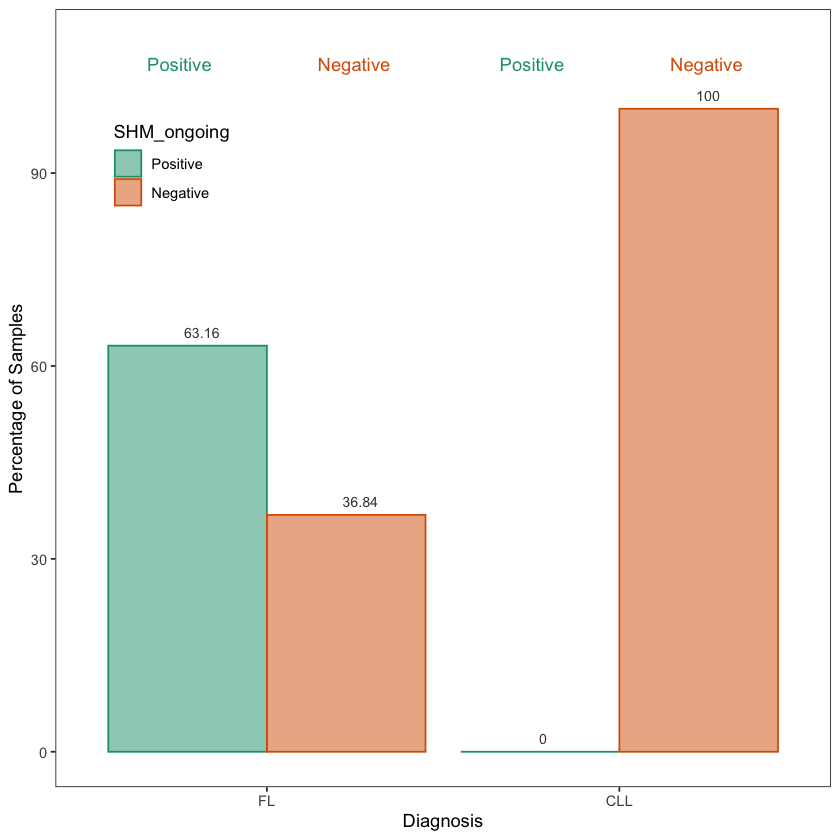

In [47]:
# coloured barplot
shM_ong <- ggplot(FL_CLL, aes(x = diagnosis, y = Percentage, fill = SHM_ongoing, colour = SHM_ongoing)) + 
  geom_bar(stat = "identity", position = "dodge", alpha = 0.5)  +
  labs(x="Diagnosis", y="Percentage of Samples") +
  theme_bw() + 
  theme(panel.grid.major = element_blank(), panel.grid.minor = element_blank()) +
  theme(legend.position = c(0.15, 0.8)) +
  geom_text(aes(label=round(Percentage,2)), position = position_dodge(0.90), size = 3, 
            vjust=-0.8, hjust=0.1, colour = "gray25") +
  ylim(0, 110) +
  geom_text(aes(label=SHM_ongoing, y = 107), position = position_dodge(0.99), show.legend = FALSE) +
  scale_fill_brewer(palette = "Dark2") +
  scale_color_brewer(palette = "Dark2")

shM_ong

fig_save(shM_ong , filename = ("figs/SHM_ongoing"), formats = c("pdf", "png"), width = 15, height =15, units = "cm", dpi = 320)

## Add clonotype data

In [48]:
clonotype <- read.csv("~/repositories/FL_10X_2/250_Clonotypes/outs/clones_2022_01_18.csv") %>% mutate(cell = gsub(".{2}$", "", barcode)) %>% 
             select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,seqConcClone, ,cluster,seqConcCount)  %>% 
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                     chain == "IGK" | chain == "IGL" ~ "LC",
                                    TRUE ~ "NA"))

In [49]:
#test

In [50]:
test <- readRDS("~/repositories/FL_10X_2/250_Clonotypes/outs/clonesB_20210803.rds") %>% mutate(cellbarcode = gsub(".{2}$", "", cell),cell = gsub("^.{4}", "", cellbarcode)) %>% 
             select(source, cell,chain,is_cell,productive,high_confidence,umis,reads,cloneAA)  %>% #seqConcClone, ,cluster,seqConcCount
             mutate(gene=case_when(chain == "IGH" ~ "HC",
                                    TRUE ~ "LC"))

### (Trully) negative cells for scSHM

In [53]:
print("number of cells in scRNA-seq")
clonotype %>% select(source, cell) %>% unique() %>% str()

[1] "number of cells in scRNA-seq"
'data.frame':	50370 obs. of  2 variables:
 $ source: chr  "K4B" "K4B" "K4B" "K4B" ...
 $ cell  : chr  "AAACCTGAGAGACGAA" "AAACCTGAGTAACCCT" "AAACCTGAGTGATCGG" "AAACCTGCAAGTCTAC" ...


In [54]:
#cellbarcode from BCR seq
df_seq_all <- Sys.glob("input/output_shm_20220819/*/consensus/*/*.csv") %>%
  purrr::map_dfr(function(x) {
    readr::read_csv(x, col_types = "cciccccc", progress = FALSE) %>%
      dplyr::mutate(subject = gsub("^.*/|.csv*$", "", x))
  })

cell_bcr <- df_seq_all %>% pull(cell) %>% unique()
print("number of cells in scBCR-seq")
df_seq_all %>% pull(cell) %>% unique() %>% str()

[1] "number of cells in scBCR-seq"
 chr [1:34299] "AAACCTGAGAGACGAA" "AAACCTGAGCCACGTC" "AAACCTGAGTAACCCT" ...


In [55]:
clonotype %>% filter(cell %in% cell_bcr) %>% pull(cell) %>% unique() %>% str

 chr [1:30686] "AAACCTGAGAGACGAA" "AAACCTGAGTAACCCT" "AAACCTGAGTGATCGG" ...


In [56]:
# positive cells
positive_cell <- df_summary %>% pull(cell) %>% unique() 

In [57]:
# false positive
false_positives <- read.csv("output/false_positives_cell_scSHM_K45678B.csv")

In [58]:
str(false_positives)

'data.frame':	28436 obs. of  2 variables:
 $ experiment: chr  "K4B" "K4B" "K4B" "K4B" ...
 $ cell      : chr  "AAACCTGAGAGACGAA" "ATCTACTAGCTCTCGG" "CACACAATCGTAGATC" "CGAGCCACACGTCTCT" ...


In [59]:
#trully negative cells with same quality as scSHM positive cells
trully_negative <- clonotype %>% filter(cell %in% cell_bcr, umis >= 10 & reads >= 25 ) %>% filter(!cell %in% positive_cell) %>% #filter positive cell out
select(source, cell) %>% unique() %>%   anti_join(false_positives) #filter false positice cells out

print("number of trully negative cells (same quality) in scBCR-seq")
str(trully_negative)

Joining with `by = join_by(cell)`


[1] "number of trully negative cells (same quality) in scBCR-seq"
'data.frame':	3431 obs. of  2 variables:
 $ source: chr  "K4B" "K4B" "K4B" "K4B" ...
 $ cell  : chr  "AAACCTGTCACGAAGG" "AAACGGGAGTGGCACA" "AAACGGGGTCTAGCGC" "AAAGCAAGTACTTAGC" ...


In [61]:
write.csv(trully_negative, "output/trully_negative_cells.csv", row.names=FALSE)

In [62]:
#add clonotype data (fist add gene column in df summary for joining)
df_summary <- df_summary %>% mutate(gene=if_else(str_sub(subject, -2) == "HC", "HC", "LC"),source = str_sub(subject, 1, 3)) %>% left_join(clonotype, c("source","cell","gene"))

In [63]:
df_summary %>% filter(is_cell == "FALSE")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,seqConcClone,cluster,seqConcCount
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>,<int>


In [64]:
df_summary %>% filter(is.na(seqConcClone))

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,seqConcClone,cluster,seqConcCount
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>,<int>
K7B_S10000-HC,TCGCGTTAGATGTAAC,157,T,CA.AT,CDR2,C-G,10-25,TRUE,None,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-HC,ATTACTCCACGAGAGT,NA,G,AC.TC,CDR3,G-T,17-54,TRUE,RCG,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-LC,GACTGCGCAGCTGTAT,35,G,TG.GG,FR1,C-G,10-32,TRUE,RCG,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-LC,GACTGCGCAGCTGTAT,67,A,GC.CT,FR1,A-T,31-8,TRUE,None,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-LC,CAGGTGCTCAGGATCT,93,A,GC.GG,CDR1,A-T,37-17,TRUE,None,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-LC,CCTCTGAGTATTCTCT,98,A,TT.TG,CDR1,A-T,7-8,TRUE,WA,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-LC,CAGGTGCTCAGGATCT,130,A,GA.CA,FR2,A-G,37-16,TRUE,WA,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-LC,CCTCTGAGTATTCTCT,211,A,GC.CC,FR3,A-G,5-7,TRUE,None,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA
K7B_S10000-LC,GACTGCGCAGCTGTAT,NA,C,AG.TG,FR4,G-T,10-14,TRUE,None,⋯,K7B,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [65]:
print("Number of FALSE cells")
df_summary %>% filter(is_cell == FALSE ) %>% pull(cell) %>% unique() %>% length()

[1] "Number of FALSE cells"


[1] 0

In [66]:
df_summary %>% filter(subject == "K4B_S8934-HC")

subject,cell,vgene_position_aligned,nucl_po,context_po,subregion,variation,umis.x,productive.x,aid_motif1,⋯,source,chain,is_cell,productive.y,high_confidence,umis.y,reads,seqConcClone,cluster,seqConcCount
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<lgl>,<lgl>,<lgl>,<int>,<int>,<int>,<int>,<int>
K4B_S8934-HC,TGTCCCAGTTTGTTGG,4,G,AG.TG,FR1,A-G,18-8,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,21,18582,5,4,130
K4B_S8934-HC,TGAGAGGCAGACTCGC,9,G,CA.CT,FR1,A-G,34-69,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,85,40086,13,4,42
K4B_S8934-HC,AGATCTGAGACCGGAT,18,G,GA.TC,FR1,A-G,6-5,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,13,28766,32,0,18
K4B_S8934-HC,AGGCCGTGTGCGCTTG,70,G,CA.CC,FR1,A-G,5-5,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,9,33874,6,2,119
K4B_S8934-HC,CTTTGCGTCAAGGTAA,186,C,TA.GC,FR3,C-T,22-22,TRUE,RCG,⋯,K4B,IGH,TRUE,TRUE,TRUE,60,55340,6,5,119
K4B_S8934-HC,GGACGTCTCGACCAGC,188,C,CG.TG,FR3,C-G,8-5,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,16,27612,827,5,1
K4B_S8934-HC,ACGTCAACACATCTTT,241,C,CG.TG,FR3,C-G,13-6,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,24,44434,48,0,11
K4B_S8934-HC,ACAGCCGAGCTGAAAT,247,C,AT.TG,FR3,C-T,5-6,TRUE,None,⋯,K4B,IGH,TRUE,TRUE,TRUE,8,43914,1044,5,1
K4B_S8934-HC,CTGCGGAGTTACAGAA,260,G,CA.CC,FR3,A-G,12-9,TRUE,WA,⋯,K4B,IGH,TRUE,TRUE,TRUE,118,39104,615,5,1


## Substitution type (spectro)

In [67]:
spectro <- df_summary %>% group_by(variation) %>% count() %>% ungroup() %>% mutate(Percentage =n * 100 / sum(n))
spectro

variation,n,Percentage
<chr>,<int>,<dbl>
A-C,28,9.523810
A-G,100,34.013605
A-T,28,9.523810
C-G,52,17.687075
C-T,60,20.408163
G-T,26,8.843537


In [68]:
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




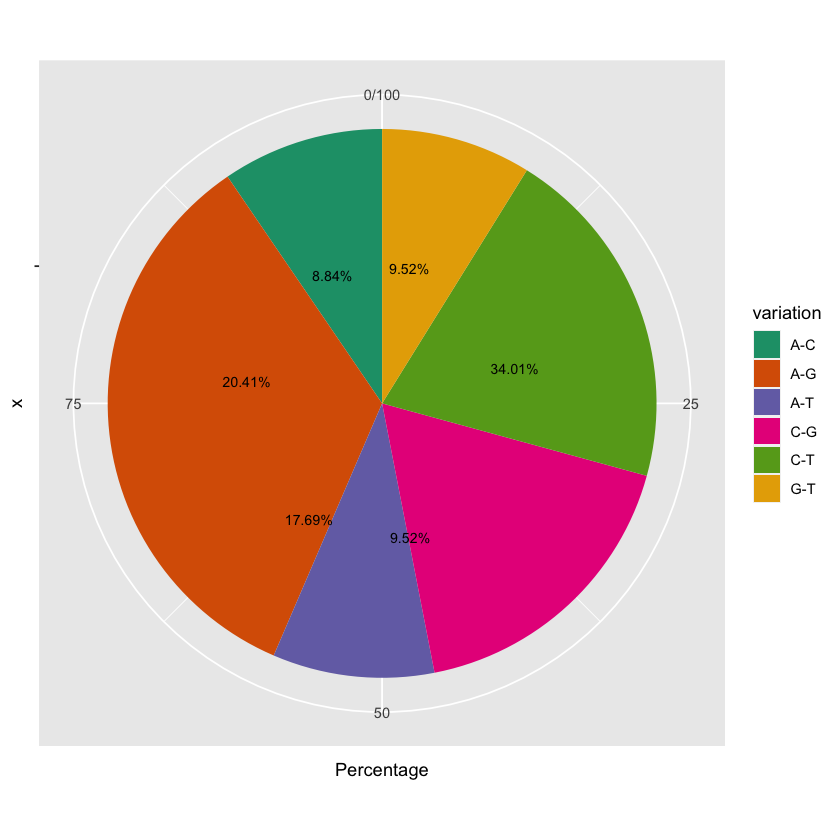

In [69]:
# pie
bp <- ggplot(spectro, aes(x="", y=Percentage, fill=variation))+
geom_bar(width = 1, stat = "identity") +
coord_polar("y", start=0) +
scale_fill_brewer(palette="Dark2") +
  geom_text(aes(y = Percentage/3 + c(0, cumsum(Percentage)[-length(Percentage)]), 
            label = percent(Percentage/100)), size=3)

bp

fig_save(bp, filename = ("figs/perc_spectro"), formats = c("pdf", "png"), width = 17, height =15, units = "cm", dpi = 320)

## (TEST) Statistical Analysis

### By sample freq

In [70]:
dat <- data.frame(
  "SHMa_positve" = c(4, 1),
  "SHMa_negative" = c(6, 5),
  row.names = c("FL", "CLL/MBL"),
  stringsAsFactors = FALSE
)
colnames(dat) <- c("SHMa_positve", "SHMa_negative")

dat

,SHMa_positve,SHMa_negative
,<dbl>,<dbl>
FL,4,6
CLL/MBL,1,5


### Expected frequencies
Remember that the Fisher’s exact test is used when there is at least one cell in the contingency table of the expected frequencies below 5. To retrieve the expected frequencies, use the chisq.test() function together with $expected:

In [71]:
chisq.test(dat)$expected

,SHMa_positve,SHMa_negative
FL,3.125,6.875
CLL/MBL,1.875,4.125


The contingency table above confirms that we should use the Fisher’s exact test instead of the Chi-square test because there is at least one cell below 5.

In [72]:
fish <- fisher.test(dat)
fish


	Fisher's Exact Test for Count Data

data:  dat
p-value = 0.5879
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
   0.2047437 196.1543656
sample estimates:
odds ratio 
  3.103683 


In [73]:
dat_s <- data.frame(
   "shm_state" = c("SHMa_positve","SHMa_negative","SHMa_positve","SHMa_negative"),
  "n" = c(4,1,2,5),
  "group" =c("FL","FL", "CLL/MBL","CLL/MBL"),
  stringsAsFactors = FALSE
)
dat_s

shm_state,n,group
<chr>,<dbl>,<chr>
SHMa_positve,4,FL
SHMa_negative,1,FL
SHMa_positve,2,CLL/MBL
SHMa_negative,5,CLL/MBL


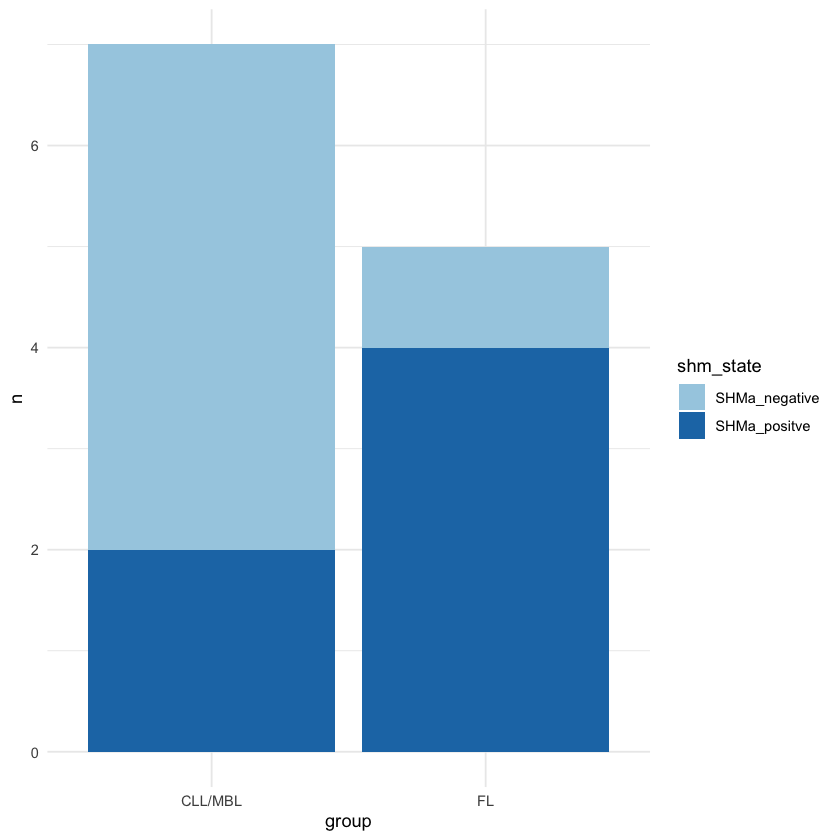

In [74]:
# Create the barplot
sample_fre <- ggplot(data=dat_s, aes(x=group, y=n, fill=shm_state)) +
  geom_bar(stat="identity")+
#  geom_text(aes(y=label_ypos, label=n), vjust=1.6, 
#            color="white", size=3.5)+
  scale_fill_brewer(palette="Paired")+
  theme_minimal()

sample_fre

fig_save(sample_fre, filename = ("figs/sample_freq"), formats = c("pdf", "png"), width = 10, height =12, units = "cm", dpi = 320)

## By cell freq

In [75]:
#summ.cllmbl <- read.csv("output/summary_CLL_MBL.csv") %>% select(-name) %>% rename("case"="subject","subject"="case", "group"="chain", "total_cell"="Total_cell") %>% mutate(diag="MBL")

In [76]:
summary.all <- summary %>% mutate(diag="FL") %>% bind_rows(summ.cllmbl)
summary.all

ERROR: Error in list2(...): object 'summ.cllmbl' not found


In [ ]:
group_by(summary.all, diag) %>%
  summarise(
    count = n(),
    mean = mean(Percentage, na.rm = TRUE),
    sd = sd(Percentage, na.rm = TRUE)
  )

In [ ]:
cell_fre <- ggboxplot(summary.all, x = "diag", y = "Percentage", 
          color = "diag", palette = c("#00AFBB", "#E7B800"),
        ylab = "Percentage of SHMa cells", xlab = "Diagnostic")

cell_fre

fig_save(cell_fre, filename = ("figs/cell_freq"), formats = c("pdf", "png"), width = 10, height =12, units = "cm", dpi = 320)

In [ ]:
# Shapiro-Wilk normality test for Men's weights
with(summary.all, shapiro.test(Percentage[diag == "FL"]))# p = 1.519e-05
# Shapiro-Wilk normality test for Women's weights
#with(summary.all, shapiro.test(Percentage[diag == "MBL"])) # p = 0.6

##### res <- wilcox.test(Percentage ~ diag, data = summary.all,
                   exact = FALSE)
res

### Figure 2

In [ ]:
overview <- read.csv("input/overview_plot.csv")

In [ ]:
#define gene order for plotting
sub_order <- overview  %>% arrange(-Nu_Cells_w_events) %>% pull(Patient_id) %>% unique()
sub_order

In [ ]:
overview[overview == 0] <- NA
overview <- overview %>% mutate(Patient_id = factor(Patient_id, levels = sub_order)) 
overview

In [ ]:
overview_expre <- overview %>% select(Patient_id,chain, Pos_SHMa_AID_pos,Pos_SHMa_AID_neg,Neg_SHMa_AID_pos,Neg_SHMa_AID_neg) %>% gather(-Patient_id,-chain, key="group",value="cells") %>%
group_by(Patient_id,chain,group) %>% mutate(Percentage =cells * 100 / sum(cells))

In [ ]:
fig_2 <- ggplot(overview, aes(fill=chain, y=Nu_Cells_w_events, x=Patient_id)) + 
    geom_bar(position="dodge", stat="identity") +
    geom_text(aes(label = Nu_Total_events),
              size = 3.5, position = position_dodge(width = 1),vjust = -0.5) + #, nudge_x = 0.25  nudge_y = 0.7
    theme_minimal() +
    theme(axis.text.x = element_text(angle = 90, vjust=0.5,size=8)) +
    scale_fill_brewer(palette="Paired") +
    scale_x_discrete(name ="Patients") +
    scale_y_continuous(name ="Number of cells") 
     

fig_2

fig_save(fig_2, filename = paste0("figs/overview",name), formats = c("pdf", "png"), width = 17, height =10, units = "cm", dpi = 320)

In [ ]:
overview_expre

In [ ]:
fig_2b <- ggplot(overview_expre, aes(fill=group, y=Percentage, x=Patient_id)) + 
    geom_bar(stat="identity") +
    theme(axis.text.x = element_text(angle = 90, vjust=0.5,size=8)) +
    facet_wrap(.~chain)
fig_2b

In [ ]:
ft2 <- ft %>% select(-class)
write.csv(ft2, "output/df_complete.csv", row.names =FALSE)

## Extract SHMss sequences for plotting of the events

In [1]:
df_summary %>% separate(umis, c("umi1", "umi2"), "-", convert = TRUE) %>% mutate(umis = umi1+umi2) #%>% pull(umis) %>% sum()

ERROR: Error in df_summary %>% separate(umis, c("umi1", "umi2"), "-", convert = TRUE) %>% : could not find function "%>%"


In [ ]:
willow_seq <- df %>% inner_join(df_summary %>% select(subject,cell,vgene_position_aligned)) %>% mutate(id=paste0(subject,"_",cell,"_",umi,"_",position,"_",vgene_position_aligned,"_",nucl)) %>% mutate(id_split=paste0(subject,"_",cell))
head(willow_seq)

In [ ]:
willow_seq  %>% str() #filter(depth > 5)

In [ ]:
length(unique(willow_seq$id_split))

In [ ]:
df_seq %>% filter(cell %in% willow_seq$cell & subject %in% willow_seq$subject) %>% 
right_join(willow_seq %>% select(subject,cell,umi,id),c("subject","cell","umi")) %>% str()
#%>% pull(umi) %>% unique() %>% str() # & subject %in% willow_seq$subject & 

In [ ]:
df_seq %>% head()

In [ ]:
for (i in willow_seq$id_split) {
    df_fi <- willow_seq %>% filter(id_split == i)
    df_seq_fil <- df_seq %>% filter(cell %in% df_fi$cell & subject %in% df_fi$subject) %>% #  cell == "AAACGGGGTATTAGCC"
#                 select(umi,aligned_consensus) 
                   right_join(df_fi %>% select(subject,cell,umi,id),c("subject","cell","umi"))  %>% select(id,consensus) 
    Xfasta <- character(nrow(df_seq_fil) * 2)
    Xfasta[c(TRUE, FALSE)] <- paste0(">", df_seq_fil$id)
    Xfasta[c(FALSE, TRUE)] <- df_seq_fil$consensus
    
    writeLines(Xfasta, paste0("output/fasta_SHM_cells/consensus",i,".fasta"))
    
}

### Extract consensus: Convert fasta file of consensus in df